Loading ensemble data...
Data Loaded. Shape: (1515, 128, 192) (Members, Lat, Lon)
Loading land mask from: /Users/ewellmeyer/Documents/research/HadGEM/hadgem_landmask_rg128.nc
Land mask shape: (128, 192)
Land points: 9296, Ocean points: 15280
Total members: 1515, Train: 1136, Test: 379

Running prediction comparison (Calculating Global RMSE for ALL members)...
 Processing lat 0/128
 Processing lat 20/128
 Processing lat 40/128
 Processing lat 60/128
 Processing lat 80/128
 Processing lat 100/128
 Processing lat 120/128

RESULTS SUMMARY

Global (All Points) - Test Set:
  Ensemble Mean RMSE:  73.9135
  Linear RMSE:         70.6786
  Quadratic RMSE:      70.2096
  Cubic RMSE:          70.2746

Land Only - Test Set:
  Ensemble Mean RMSE:  68.4025
  Linear RMSE:         65.4718
  Quadratic RMSE:      64.9985
  Cubic RMSE:          65.1309

Saved results to: /Users/ewellmeyer/Documents/research/HadGEM/polynomial_regression_analysis.npz
Shape of member_rmse arrays: (1515,)


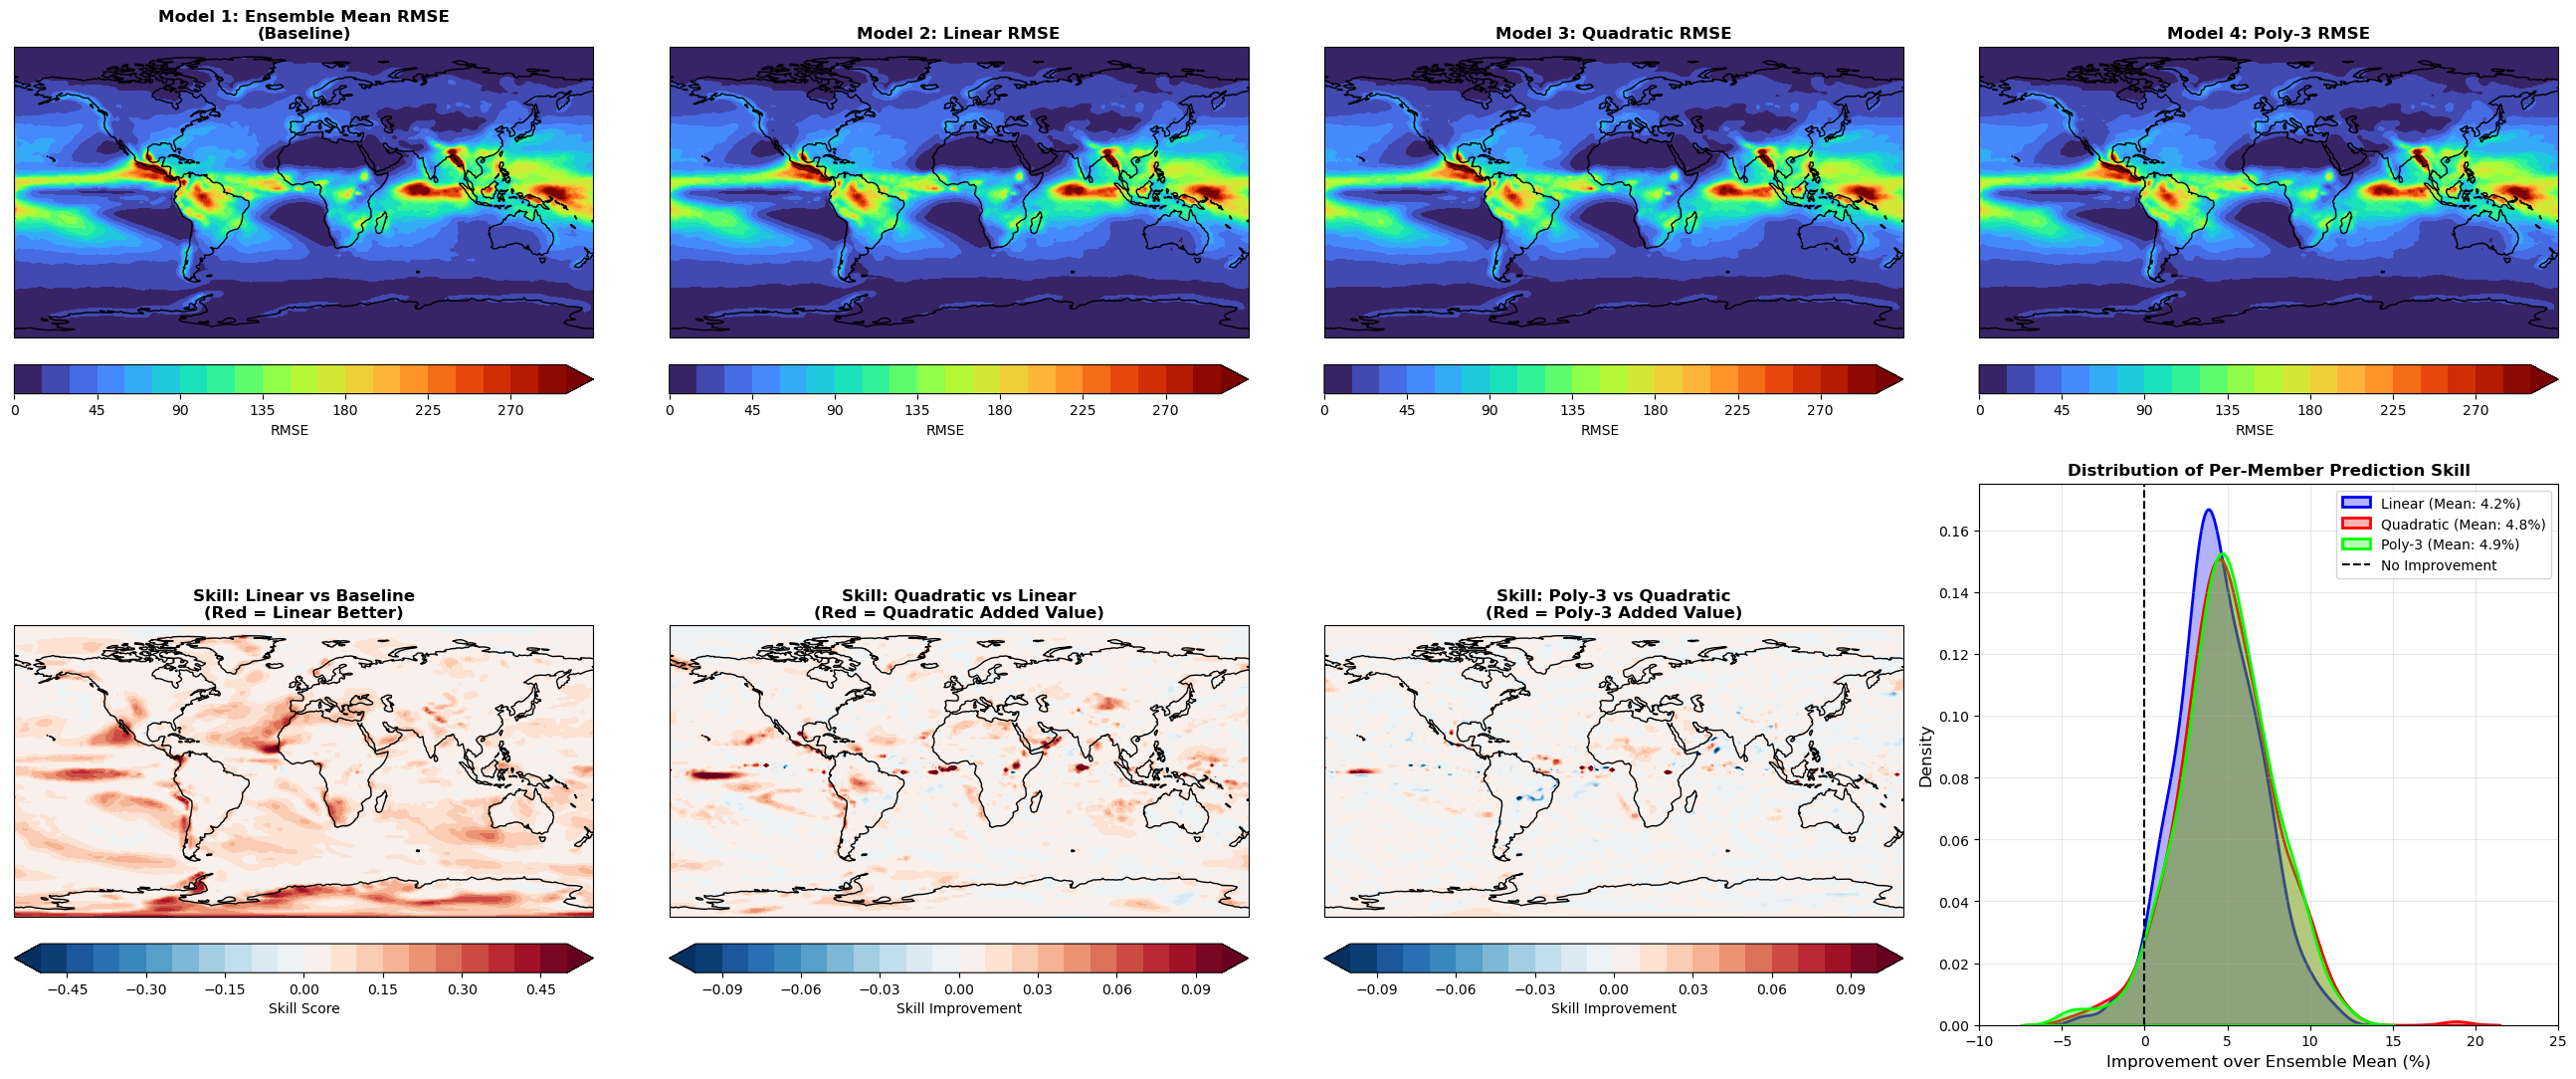

In [1]:
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# --------------------------
# Config / Paths
# --------------------------
data_dir = "/Users/ewellmeyer/Documents/research/HadGEM"

# New consolidated files
input_file = os.path.join(data_dir, "GA789_PR_his_rg128.nc")
truth_file = os.path.join(data_dir, "GA789_dPdK_rg128.nc")
land_mask_file = os.path.join(data_dir, "hadgem_landmask_rg128.nc")
land_mask_var = "land_mask"

print("Loading ensemble data...")

# --------------------------
# Data Loading
# --------------------------
# Load Historical Climatology (Predictors - X)
ds_in = xr.open_dataset(input_file)
# Assuming structure is (Vars, Member, Lat, Lon) or (Member, Lat, Lon)
X_data = ds_in.to_array().values.squeeze()
ds_in.close()

# Load Truth/Change (Targets - y)
ds_true = xr.open_dataset(truth_file)
y_data = ds_true.to_array().values.squeeze()
ds_true.close()

# Handle potential singleton dimensions (e.g., (1, Members, Lat, Lon))
if X_data.ndim == 4:
    X_data = X_data[0]
if y_data.ndim == 4:
    y_data = y_data[0]

# Ensure shapes match
assert X_data.shape == y_data.shape, f"Shape mismatch: X {X_data.shape} vs y {y_data.shape}"

n_members, n_lat, n_lon = X_data.shape
print(f"Data Loaded. Shape: {X_data.shape} (Members, Lat, Lon)")

# Load coordinates
ds_ref = xr.open_dataset(input_file)
lats = ds_ref["latitude"].values
lons = ds_ref["longitude"].values
ds_ref.close()

# Load Land Mask
print(f"Loading land mask from: {land_mask_file}")
try:
    ds_mask = xr.open_dataset(land_mask_file)
    if land_mask_var not in ds_mask:
        land_mask_var = list(ds_mask.data_vars)[0]

    land_mask = ds_mask[land_mask_var].values

    if land_mask.ndim == 3:
        land_mask = land_mask[0]

    land_mask = land_mask.astype(bool)
    ds_mask.close()
    print(f"Land mask shape: {land_mask.shape}")
    print(f"Land points: {np.sum(land_mask)}, Ocean points: {np.sum(~land_mask)}")
except Exception as e:
    print(f"Warning: Could not load land mask: {e}")
    print("Using all points (no land mask applied)")
    land_mask = np.ones((n_lat, n_lon), dtype=bool)

# --------------------------
# Train/Test Split
# --------------------------
indices = np.arange(n_members)
train_idx, test_idx = train_test_split(indices, test_size=0.25, random_state=42)
print(f"Total members: {n_members}, Train: {len(train_idx)}, Test: {len(test_idx)}")

# --------------------------
# Initialize Metrics
# --------------------------
# Maps (Test RMSE only)
rmse_m1_map = np.zeros((n_lat, n_lon))  # Mean
rmse_m2_map = np.zeros((n_lat, n_lon))  # Linear
rmse_m3_map = np.zeros((n_lat, n_lon))  # Quadratic
rmse_m4_map = np.zeros((n_lat, n_lon))  # Cubic

# Global Accumulators (All Members)
global_sse_m1 = np.zeros(n_members)
global_sse_m2 = np.zeros(n_members)
global_sse_m3 = np.zeros(n_members)
global_sse_m4 = np.zeros(n_members)
total_weight_accum = 0.0

# Land-Only Accumulators (All Members)
global_sse_m1_land = np.zeros(n_members)
global_sse_m2_land = np.zeros(n_members)
global_sse_m3_land = np.zeros(n_members)
global_sse_m4_land = np.zeros(n_members)
total_weight_land_accum = 0.0

# --------------------------
# Main Analysis Loop
# --------------------------
print("\nRunning prediction comparison (Calculating Global RMSE for ALL members)...")

# Latitude weights
lat_weights = np.cos(np.deg2rad(lats))

for i in range(n_lat):
    if i % 20 == 0: print(f" Processing lat {i}/{n_lat}")
    
    w_lat = lat_weights[i]

    for j in range(n_lon):
        # Extract ALL data for this grid cell
        # X: Historical Precip (Feature)
        X_all = X_data[:, i, j].reshape(-1, 1)
        # y: Change in Precip (Target)
        y_all = y_data[:, i, j]
        
        # Split for TRAINING the models
        X_train, y_train = X_all[train_idx], y_all[train_idx]
        
        # Test set for map metrics
        X_test, y_test = X_all[test_idx], y_all[test_idx]
        
        is_land = land_mask[i, j]
        
        # Skip grid cells with no variance (e.g. masked ocean or constant values)
        if np.std(X_train) > 1e-10 and np.std(y_train) > 1e-10:
            
            # --- MODEL 1: Ensemble Mean ---
            pred_ens_mean = np.mean(y_train) 
            
            # Map Metric (Test Only)
            y_pred_test_m1 = np.full_like(y_test, pred_ens_mean)
            rmse_m1_map[i, j] = np.sqrt(mean_squared_error(y_test, y_pred_test_m1))
            
            # Global Metric (ALL Members)
            y_pred_all_m1 = np.full_like(y_all, pred_ens_mean)
            se_m1 = (y_pred_all_m1 - y_all)**2
            global_sse_m1 += se_m1 * w_lat
            
            if is_land: global_sse_m1_land += se_m1 * w_lat
            
            
            # --- MODEL 2: Linear Regression ---
            model_lin = LinearRegression()
            model_lin.fit(X_train, y_train)
            
            # Map Metric
            y_pred_test_m2 = model_lin.predict(X_test)
            rmse_m2_map[i, j] = np.sqrt(mean_squared_error(y_test, y_pred_test_m2))
            
            # Global Metric
            y_pred_all_m2 = model_lin.predict(X_all)
            se_m2 = (y_pred_all_m2 - y_all)**2
            global_sse_m2 += se_m2 * w_lat
            
            if is_land: global_sse_m2_land += se_m2 * w_lat


            # --- MODEL 3: Quadratic (Poly 2) ---
            model_quad = make_pipeline(PolynomialFeatures(2), LinearRegression())
            model_quad.fit(X_train, y_train)
            
            # Map Metric
            y_pred_test_m3 = model_quad.predict(X_test)
            rmse_m3_map[i, j] = np.sqrt(mean_squared_error(y_test, y_pred_test_m3))
            
            # Global Metric
            y_pred_all_m3 = model_quad.predict(X_all)
            se_m3 = (y_pred_all_m3 - y_all)**2
            global_sse_m3 += se_m3 * w_lat
            
            if is_land: global_sse_m3_land += se_m3 * w_lat


            # --- MODEL 4: Poly 3 (Cubic) ---
            model_poly3 = make_pipeline(PolynomialFeatures(3), LinearRegression())
            model_poly3.fit(X_train, y_train)
            
            # Map Metric
            y_pred_test_m4 = model_poly3.predict(X_test)
            y_pred_test_m4 = np.clip(y_pred_test_m4, -1000, 1000) # Safety clip
            rmse_m4_map[i, j] = np.sqrt(mean_squared_error(y_test, y_pred_test_m4))
            
            # Global Metric
            y_pred_all_m4 = model_poly3.predict(X_all)
            y_pred_all_m4 = np.clip(y_pred_all_m4, -1000, 1000)
            se_m4 = (y_pred_all_m4 - y_all)**2
            global_sse_m4 += se_m4 * w_lat
            
            if is_land: global_sse_m4_land += se_m4 * w_lat

            
            # Accumulate weights
            total_weight_accum += w_lat
            if is_land:
                total_weight_land_accum += w_lat
                
        else:
            rmse_m1_map[i, j] = np.nan
            rmse_m2_map[i, j] = np.nan
            rmse_m3_map[i, j] = np.nan
            rmse_m4_map[i, j] = np.nan

# --------------------------
# Calculate Final RMSE
# --------------------------
# Per-Member Global RMSE (For ALL members)
member_rmse_m1 = np.sqrt(global_sse_m1 / total_weight_accum)
member_rmse_m2 = np.sqrt(global_sse_m2 / total_weight_accum)
member_rmse_m3 = np.sqrt(global_sse_m3 / total_weight_accum)
member_rmse_m4 = np.sqrt(global_sse_m4 / total_weight_accum)

# Per-Member Land-Only RMSE
member_rmse_m1_land = np.sqrt(global_sse_m1_land / total_weight_land_accum)
member_rmse_m2_land = np.sqrt(global_sse_m2_land / total_weight_land_accum)
member_rmse_m3_land = np.sqrt(global_sse_m3_land / total_weight_land_accum)
member_rmse_m4_land = np.sqrt(global_sse_m4_land / total_weight_land_accum)

# --------------------------
# Summary & Save
# --------------------------
print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"\nGlobal (All Points) - Test Set:")
print(f"  Ensemble Mean RMSE:  {np.mean(member_rmse_m1[test_idx]):.4f}")
print(f"  Linear RMSE:         {np.mean(member_rmse_m2[test_idx]):.4f}")
print(f"  Quadratic RMSE:      {np.mean(member_rmse_m3[test_idx]):.4f}")
print(f"  Cubic RMSE:          {np.mean(member_rmse_m4[test_idx]):.4f}")
print(f"\nLand Only - Test Set:")
print(f"  Ensemble Mean RMSE:  {np.mean(member_rmse_m1_land[test_idx]):.4f}")
print(f"  Linear RMSE:         {np.mean(member_rmse_m2_land[test_idx]):.4f}")
print(f"  Quadratic RMSE:      {np.mean(member_rmse_m3_land[test_idx]):.4f}")
print(f"  Cubic RMSE:          {np.mean(member_rmse_m4_land[test_idx]):.4f}")

save_path = os.path.join(data_dir, "polynomial_regression_analysis.npz")

np.savez_compressed(
    save_path,
    lats=lats.astype(np.float32),
    lons=lons.astype(np.float32),
    
    # Land mask
    land_mask=land_mask.astype(bool),
    
    # Spatial Maps (Test RMSE)
    rmse_m1_map=rmse_m1_map.astype(np.float32),
    rmse_m2_map=rmse_m2_map.astype(np.float32),
    rmse_m3_map=rmse_m3_map.astype(np.float32),
    rmse_m4_map=rmse_m4_map.astype(np.float32),
    
    # Per-Member Global RMSE (All Members)
    member_rmse_mean=member_rmse_m1.astype(np.float32),
    member_rmse_linear=member_rmse_m2.astype(np.float32),
    member_rmse_quad=member_rmse_m3.astype(np.float32),
    member_rmse_poly3=member_rmse_m4.astype(np.float32),
    
    # Per-Member Land-Only RMSE
    member_rmse_mean_land=member_rmse_m1_land.astype(np.float32),
    member_rmse_linear_land=member_rmse_m2_land.astype(np.float32),
    member_rmse_quad_land=member_rmse_m3_land.astype(np.float32),
    member_rmse_poly3_land=member_rmse_m4_land.astype(np.float32),
    
    # Metadata
    train_idx=train_idx.astype(np.int32),
    test_idx=test_idx.astype(np.int32),
)

print(f"\nSaved results to: {save_path}")
print(f"Shape of member_rmse arrays: {member_rmse_m1.shape}")

import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(26, 12))

# Plot 1: Baseline
ax1 = plt.subplot(2, 4, 1, projection=ccrs.PlateCarree())
im1 = ax1.contourf(lons, lats, rmse_m1_map, levels=np.linspace(0, 300, 21), cmap='turbo', extend="max", transform=ccrs.PlateCarree())
ax1.coastlines()
ax1.set_title('Model 1: Ensemble Mean RMSE\n(Baseline)', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, label='RMSE')

# Plot 2: Linear
ax2 = plt.subplot(2, 4, 2, projection=ccrs.PlateCarree())
im2 = ax2.contourf(lons, lats, rmse_m2_map, levels=np.linspace(0, 300, 21), cmap='turbo', extend="max", transform=ccrs.PlateCarree())
ax2.coastlines()
ax2.set_title('Model 2: Linear RMSE', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, label='RMSE')

# Plot 3: Quadratic
ax3 = plt.subplot(2, 4, 3, projection=ccrs.PlateCarree())
im3 = ax3.contourf(lons, lats, rmse_m3_map, levels=np.linspace(0, 300, 21), cmap='turbo', extend="max", transform=ccrs.PlateCarree())
ax3.coastlines()
ax3.set_title('Model 3: Quadratic RMSE', fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, label='RMSE')

# Plot 4: Poly 3
ax4 = plt.subplot(2, 4, 4, projection=ccrs.PlateCarree())
im4 = ax4.contourf(lons, lats, rmse_m4_map, levels=np.linspace(0, 300, 21), cmap='turbo', extend="max", transform=ccrs.PlateCarree())
ax4.coastlines()
ax4.set_title('Model 4: Poly-3 RMSE', fontsize=12, fontweight='bold')
plt.colorbar(im4, ax=ax4, orientation='horizontal', pad=0.05, label='RMSE')


# Plot 5: Skill Linear vs Baseline
ax5 = plt.subplot(2, 4, 5, projection=ccrs.PlateCarree())
skill_lin = 1 - (rmse_m2_map / rmse_m1_map)
im5 = ax5.contourf(lons, lats, skill_lin, levels=np.linspace(-0.5, 0.5, 21), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
ax5.coastlines()
ax5.set_title('Skill: Linear vs Baseline\n(Red = Linear Better)', fontsize=12, fontweight='bold')
plt.colorbar(im5, ax=ax5, orientation='horizontal', pad=0.05, label='Skill Score')

# Plot 6: Skill Quadratic vs Linear
ax6 = plt.subplot(2, 4, 6, projection=ccrs.PlateCarree())
skill_quad = 1 - (rmse_m3_map / rmse_m2_map)
im6 = ax6.contourf(lons, lats, skill_quad, levels=np.linspace(-0.1, 0.1, 21), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
ax6.coastlines()
ax6.set_title('Skill: Quadratic vs Linear\n(Red = Quadratic Added Value)', fontsize=12, fontweight='bold')
plt.colorbar(im6, ax=ax6, orientation='horizontal', pad=0.05, label='Skill Improvement')

# Plot 7: Skill Poly-3 vs Quadratic
ax7 = plt.subplot(2, 4, 7, projection=ccrs.PlateCarree())
skill_poly3 = 1 - (rmse_m4_map / rmse_m3_map)
im7 = ax7.contourf(lons, lats, skill_poly3, levels=np.linspace(-0.1, 0.1, 21), cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
ax7.coastlines()
ax7.set_title('Skill: Poly-3 vs Quadratic\n(Red = Poly-3 Added Value)', fontsize=12, fontweight='bold')
plt.colorbar(im7, ax=ax7, orientation='horizontal', pad=0.05, label='Skill Improvement')

# Plot 8: Distribution of Per-Member Percent Improvement (CORRECTED)
ax8 = plt.subplot(2, 4, 8)

# Use per-member RMSE values instead of spatial maps
# Use the per-member arrays produced in the analysis (member_rmse_m1..m4)
member_rmse_mean = member_rmse_m1[test_idx]  # Baseline
member_rmse_linear = member_rmse_m2[test_idx]
member_rmse_quad = member_rmse_m3[test_idx]
member_rmse_poly3 = member_rmse_m4[test_idx]

# Calculate per-member improvement percentage
imp_lin = (1 - member_rmse_linear / member_rmse_mean) * 100
imp_quad = (1 - member_rmse_quad / member_rmse_mean) * 100
imp_poly3 = (1 - member_rmse_poly3 / member_rmse_mean) * 100

# KDE plots
sns.kdeplot(data=imp_lin, ax=ax8, color='blue', fill=True, alpha=0.3,
            label=f'Linear (Mean: {np.median(imp_lin):.1f}%)', linewidth=2)
sns.kdeplot(data=imp_quad, ax=ax8, color='red', fill=True, alpha=0.3,
            label=f'Quadratic (Mean: {np.median(imp_quad):.1f}%)', linewidth=2)
sns.kdeplot(data=imp_poly3, ax=ax8, color='lime', fill=True, alpha=0.3,
            label=f'Poly-3 (Mean: {np.median(imp_poly3):.1f}%)', linewidth=2)

ax8.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='No Improvement')
ax8.set_xlabel('Improvement over Ensemble Mean (%)', fontsize=12)
ax8.set_ylabel('Density', fontsize=12)
ax8.set_title('Distribution of Per-Member Prediction Skill', fontsize=12, fontweight='bold')
ax8.set_xlim(-10, 25)
ax8.legend(loc='upper right')
ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()